### **SIM CAFE — Single-Agent RL with SB3**

A custom Gymnasium environment where the agent runs a small cafe during a morning rush.
Customers queue up with orders (espresso, latte, pastry), each has a **patience timer** and a **tip that decays as they wait**. The agent decides **who to serve next**.

**Why this problem is interesting:**
- It's a *scheduling* problem, not a control problem — the agent has to learn priority.
- Stations are limited (1 espresso machine, 1 steamer, 1 oven), so the agent can't just "do everything at once".
- Tips decay with wait time → there's pressure to serve fast, but also to pick the high-value orders.

**Setup:**
- Discrete action space: `0 = idle`, `1..4 = serve customer in queue slot k`
- 27-dim observation: queue contents + station busy times
- Episode length is controlled by `EPISODE_LENGTH` in `cafe_env.py` (one rush)


In [1]:
import time
import numpy as np
from cafe_env import CafeBaristaEnv, EPISODE_LENGTH, QUEUE_SLOT_OBS_DIM
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

# Reward objective switches. Enable revenue, tips, or both.
OPT_REVENUE = True
OPT_TIPS = False
ENV_KWARGS = {'opt_revenue': OPT_REVENUE, 'opt_tips': OPT_TIPS}


/home/jaumemanero/RL/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-05-21 08:04:00.893877: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 08:04:00.926300: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jaumemanero/RL/lib/python3.10/site-packages/google/a

In [2]:
env = CafeBaristaEnv(seed=0, **ENV_KWARGS)
print(f'Observation space: {env.observation_space}')
print(f'Action space:      {env.action_space}')
print(f'  Actions: 0=idle, 1..4=serve queue slot k')
print(f'Reward objective: revenue={OPT_REVENUE}, tips={OPT_TIPS}')

obs, info = env.reset(seed=0)
print(f'\nInitial obs (first 10 dims): {obs[:10]}')
print(f'Initial info: {info}')

Observation space: Box(0.0, 1.0, (27,), float32)
Action space:      Discrete(5)
  Actions: 0=idle, 1..4=serve queue slot k
Reward objective: revenue=True, tips=False

Initial obs (first 10 dims): [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
Initial info: {'t': 0, 'queue_size': 1, 'busy_stations': 0, 'revenue': 0.0, 'tips': 0.0, 'objective_reward': 0.0, 'penalties': 0.0, 'idle_penalties': 0.0, 'leave_penalties': 0.0, 'customers_left': 0, 'opt_revenue': True, 'opt_tips': False, 'revenue_reward_multiplier': 1.0, 'tip_reward_multiplier': 5.0}


In [3]:
# Random policy baseline — how well does pure chance do?
def run_episode(env, policy_fn, seed=None):
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    while True:
        action = policy_fn(obs)
        obs, r, term, trunc, _ = env.step(action)
        total_reward += r
        steps += 1
        if term or trunc:
            break
    return total_reward, steps

rng = np.random.default_rng(0)
random_rewards = [run_episode(env, lambda o: int(rng.integers(0, env.action_space.n)), seed=i)[0]
                  for i in range(10)]
print(f'Random policy:    mean={np.mean(random_rewards):6.2f}   std={np.std(random_rewards):.2f}')

Random policy:    mean= 54.30   std=24.87


In [4]:
# Smarter heuristic: serve the FIRST occupied slot that is not already being served.
# Each queue slot has QUEUE_SLOT_OBS_DIM obs dims; offsets 4 and 5 are 'present' and 'being served'.
def fifo_policy(obs):
    for slot in range(4):  # MAX_QUEUE = 4
        base = slot * QUEUE_SLOT_OBS_DIM
        present = obs[base + 4] > 0.5
        being_served = obs[base + 5] > 0.5
        if present and not being_served:
            return slot + 1
    return 0

heuristic_rewards = [run_episode(env, fifo_policy, seed=i)[0] for i in range(10)]
print(f'FIFO heuristic:   mean={np.mean(heuristic_rewards):6.2f}   std={np.std(heuristic_rewards):.2f}')
print('\nGoal: train an RL agent that beats both of these.')


FIFO heuristic:   mean=176.82   std=36.91

Goal: train an RL agent that beats both of these.


#### **Verify the env is SB3-compatible**

In [5]:
from stable_baselines3.common.env_checker import check_env

check_env(CafeBaristaEnv(seed=0, **ENV_KWARGS))
print('✅ Env passes SB3 checks')

✅ Env passes SB3 checks


#### **Train PPO**

PPO is a solid default for discrete action spaces. We use a vectorized env (multiple parallel cafes) to speed up training.

In [6]:


def make_env(seed):
    def _thunk():
        env = CafeBaristaEnv(seed=seed, **ENV_KWARGS)
        return Monitor(env)
    return _thunk

N_ENVS = 8
vec_env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])

model = PPO(
    'MlpPolicy',
    vec_env,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    learning_rate=3e-4,
    verbose=0,
)

# 80k timesteps trains in ~30s on CPU. Bump higher for fun.
model.learn(total_timesteps=500_000)
model.save('ppo_cafe_barista')
print('\n Training done. Model saved as ppo_cafe_barista.zip')


 Training done. Model saved as ppo_cafe_barista.zip


#### **Evaluate the trained agent**

In [7]:
eval_env = CafeBaristaEnv(seed=0, **ENV_KWARGS)

def model_policy(obs):
    a, _ = model.predict(obs, deterministic=True)
    return int(a)

ppo_rewards = [run_episode(eval_env, model_policy, seed=1000 + i)[0] for i in range(20)]

print(f'PPO:    mean={np.mean(ppo_rewards):6.2f}   std={np.std(ppo_rewards):.2f}')
print(f'FIFO:   mean={np.mean(heuristic_rewards):6.2f}   std={np.std(heuristic_rewards):.2f}')
print(f'Random: mean={np.mean(random_rewards):6.2f}   std={np.std(random_rewards):.2f}')

PPO:    mean=256.14   std=29.13
FIFO:   mean=176.82   std=36.91
Random: mean= 54.30   std=24.87


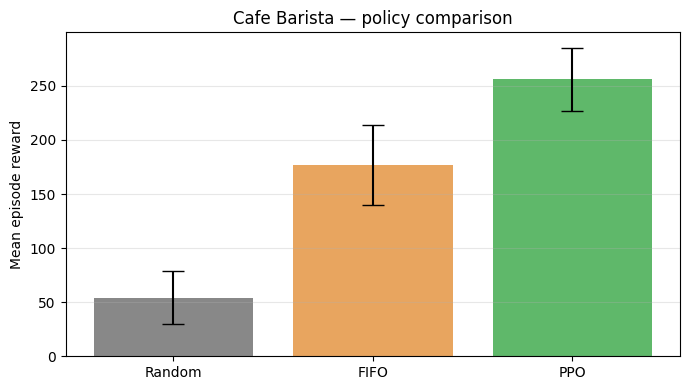

In [8]:
import matplotlib.pyplot as plt

labels = ['Random', 'FIFO', 'PPO']
data = [random_rewards, heuristic_rewards, ppo_rewards]
means = [np.mean(d) for d in data]
stds = [np.std(d) for d in data]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, means, yerr=stds, color=['#888', '#e8a55f', '#5fb86a'], capsize=8)
ax.set_ylabel('Mean episode reward')
ax.set_title('Cafe Barista — policy comparison')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Watch the agent play (`render_mode='human'`)**

This opens a pygame window with the pixel-art cafe. The barista is on the left, customers queue on the right with their orders in thought bubbles and patience bars at their feet. Stations at the top change between green (ready) and red (busy).

**Note:** this needs a display. If you're on a server or in a headless notebook, skip to section 7 to save frames as a GIF instead.

In [9]:
# Comment this cell out if you're running headless
PYGAME_STEP_DELAY = 0.25  # seconds; increase to slow the episode down further

render_env = CafeBaristaEnv(render_mode='human', seed=42, **ENV_KWARGS)
obs, _ = render_env.reset(seed=42)
total = 0.0
for _ in range(EPISODE_LENGTH):
    a, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = render_env.step(int(a))
    total += r
    time.sleep(PYGAME_STEP_DELAY)
    if term or trunc:
        break
print(f'Episode total reward: {total:.1f}')
render_env.close()


Episode total reward: 291.1


#### **Save a GIF of an episode**

In [10]:
from PIL import Image

GIF_FRAME_DURATION_MS = 300  # larger value = slower playback
GIF_PATH = 'cafe_episode.gif'

gif_env = CafeBaristaEnv(render_mode='rgb_array', seed=42, **ENV_KWARGS)
obs, info = gif_env.reset(seed=42)
frames = [Image.fromarray(gif_env.render())]
total_reward = 0.0

for _ in range(EPISODE_LENGTH):
    a, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, info = gif_env.step(int(a))
    total_reward += r
    frames.append(Image.fromarray(gif_env.render()))
    if term or trunc:
        break
gif_env.close()

frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=frames[1:],
    duration=GIF_FRAME_DURATION_MS,
)

print(f'Policy: PPO')
print(f'Objective: revenue={OPT_REVENUE}, tips={OPT_TIPS}')
print(f"Reward multipliers: revenue={info['revenue_reward_multiplier']:.1f}, tips={info['tip_reward_multiplier']:.1f}")
print(f'Episode reward: {total_reward:.2f}')
print(f"Objective reward: {info['objective_reward']:.2f}")
print(f"Penalties: {info['penalties']:.2f}")
print(f"Revenue: ${info['revenue']:.2f}")
print(f"Tips: ${info['tips']:.2f}")
print(f"Customers left: {info['customers_left']}")
print(f'Saved {GIF_PATH} with {len(frames)} frames')


Policy: PPO
Objective: revenue=True, tips=False
Reward multipliers: revenue=1.0, tips=5.0
Episode reward: 291.10
Objective reward: 379.00
Penalties: -87.90
Revenue: $379.00
Tips: $95.43
Customers left: 17
Saved cafe_episode.gif with 121 frames


#### **Proposals for .env modification**
- Train longer (200k+ steps) and watch reward keep climbing.
- Swap PPO for **DQN** or **A2C** — same env, just change the import.
- **Curriculum**: start with `ARRIVAL_PROB = 0.2`, ramp to `0.5` (modify in `cafe_env.py`).
- Add **VIP customers** with 3x tip but lower patience.
- Add a **broken station** event with small probability — does the agent learn to route around it?
- Multi-agent: two baristas sharing one set of stations (Phase 2).
